# Quickstart: NOAA GEFS forecasts and analysis, virtual - dynamical.org Icechunk Zarr

A brief introduction to the suite of NOAA GEFS forecast and analysis virtual datasets transformed into an analysis-ready, cloud-optimized format by dynamical.org.

These virtual datasets include all the model runs, forecast steps, and vertical levels produced by GEFS.

GEFS publishes a subset of variables at 0.25 degree resolution out to 10 days. It also publishes all variables at 0.5 degree resolution out to 16 and 35 days. The 35-day is issued once per day, while the 10- and 16-day are issued four times per day.

The four datasets here are optimized for spatial (map) access patterns. Use the time-optimized [NOAA GEFS analysis](https://dynamical.org/catalog/noaa-gefs-analysis/) and [NOAA GEFS forecast, 35 day](https://dynamical.org/catalog/noaa-gefs-forecast-35-day/) for faster time-series access if you need only a portion of the world.

Dataset documentation:
- Analysis, 0.25 degree: https://dynamical.org/catalog/noaa-gefs-analysis-0-25-degree-virtual/
- Forecast, 10 day, 0.25 degree: https://dynamical.org/catalog/noaa-gefs-forecast-10-day-0-25-degree-virtual/
- Forecast, 16 day, 0.5 degree: https://dynamical.org/catalog/noaa-gefs-forecast-16-day-0-5-degree-virtual/
- Forecast, 35 day, 0.5 degree: https://dynamical.org/catalog/noaa-gefs-forecast-35-day-0-5-degree-virtual/


In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [2]:
# TEMPORARY: these datasets are not in the dynamical.org catalog yet, so this cell opens their
# Icechunk stores directly. Once they are published, replace this whole cell with:
#
#     import dynamical_catalog
#
#     analysis = dynamical_catalog.open("noaa-gefs-analysis-0-25-degree-virtual", chunks=None)
#     forecast_10d = dynamical_catalog.open("noaa-gefs-forecast-10-day-0-25-degree-virtual", chunks=None)
#     forecast_16d = dynamical_catalog.open("noaa-gefs-forecast-16-day-0-5-degree-virtual", chunks=None)
#     forecast_35d_pressure = dynamical_catalog.open("noaa-gefs-forecast-35-day-0-5-degree-virtual", group="pressure_level", chunks=None)
#     forecast_16d_height = dynamical_catalog.open("noaa-gefs-forecast-16-day-0-5-degree-virtual", group="height_above_mean_sea_level", chunks=None)
#     forecast
import icechunk
import xarray as xr


def open_virtual(dataset_id, **kwargs):
    # Chunks reference NOAA's public GEFS archive, which icechunk must be allowed to read anonymously.
    authorize = icechunk.containers_credentials(
        {"s3://noaa-gefs-pds/": icechunk.s3_anonymous_credentials()}
    )
    storage = icechunk.s3_storage(
        bucket="dynamical-noaa-gefs", prefix=f"{dataset_id}/v0.1.0.icechunk", region="us-west-2", anonymous=True
    )
    repo = icechunk.Repository.open(storage, authorize_virtual_chunk_access=authorize)
    return xr.open_zarr(repo.readonly_session("main").store, consolidated=True, **kwargs)


analysis = open_virtual("noaa-gefs-analysis-0-25-degree-virtual", chunks=None)
forecast_10d = open_virtual("noaa-gefs-forecast-10-day-0-25-degree-virtual", chunks=None)
forecast_16d = open_virtual("noaa-gefs-forecast-16-day-0-5-degree-virtual", chunks=None)
forecast_35d_pressure = open_virtual("noaa-gefs-forecast-35-day-0-5-degree-virtual", group="pressure_level", chunks=None)
forecast_16d_height = open_virtual("noaa-gefs-forecast-16-day-0-5-degree-virtual", group="height_above_mean_sea_level", chunks=None)
forecast_10d

<xarray.Dataset> Size: 7PB
Dimensions:                                            (init_time: 8732,
                                                        ensemble_member: 31,
                                                        lead_time: 81,
                                                        latitude: 721,
                                                        longitude: 1440)
Coordinates:
  * init_time                                          (init_time) datetime64[ns] 70kB ...
    expected_forecast_length                           (init_time) timedelta64[us] 70kB ...
  * ensemble_member                                    (ensemble_member) int16 62B ...
  * lead_time                                          (lead_time) timedelta64[us] 648B ...
    valid_time                                         (init_time, lead_time) datetime64[ns] 6MB ...
  * latitude                                           (latitude) float64 6kB ...
  * longitude                                          (longitude) float64 12kB ...
    spatial_ref                                        int64 8B ...
Data variables: (12/38)
    categorical_ice_pellets_surface                    (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    categorical_freezing_rain_surface                  (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    categorical_rain_surface                           (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_inhibition_surface                      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_inhibition_180_0mb                      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    convective_available_potential_energy_180_0mb      (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    ...                                                 ...
    volumetric_soil_moisture_0_10cm                    (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    upward_short_wave_radiation_flux_surface           (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    upward_long_wave_radiation_flux_top_of_atmosphere  (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_u_10m                                         (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_gust_surface                                  (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
    wind_v_10m                                         (init_time, ensemble_member, lead_time, latitude, longitude) float64 182TB ...
Attributes:
    dataset_id:           noaa-gefs-forecast-10-day-0-25-degree-virtual
    dataset_version:      0.1.0
    name:                 NOAA GEFS forecast, 10 day, 0.25 degree, virtual
    description:          Weather forecasts from the Global Ensemble Forecast...
    attribution:          NOAA NWS NCEP GEFS data processed by dynamical.org ...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2020-10-01 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-240 hours ahead
    forecast_resolution:  Forecast step 3 hourly

As you can see above, these ensemble forecast datasets have a lot of dimensions:
- Each `init_time` is a model run, which has many `ensemble_member`s, each of which steps forward into the future along the `lead_time` dimension.
- At each forecast step, there's a whole 2D or 3D field covering the globe. They're indexed by `latitude` and `longitude`, plus `pressure_level`, `model_level`, or `height_above_mean_sea_level` if you opened one of those groups.

The analysis dataset, shown below, keeps it simple: dimensions `time`, `latitude`, and `longitude`.


In [3]:
analysis

<xarray.Dataset> Size: 6TB
Dimensions:                                            (time: 17464,
                                                        latitude: 721,
                                                        longitude: 1440)
Coordinates:
  * time                                               (time) datetime64[ns] 140kB ...
  * latitude                                           (latitude) float64 6kB ...
  * longitude                                          (longitude) float64 12kB ...
    spatial_ref                                        int64 8B ...
Data variables: (12/38)
    categorical_freezing_rain_surface                  (time, latitude, longitude) float64 145GB ...
    categorical_rain_surface                           (time, latitude, longitude) float64 145GB ...
    categorical_ice_pellets_surface                    (time, latitude, longitude) float64 145GB ...
    categorical_snow_surface                           (time, latitude, longitude) float64 145GB ...
    convective_available_potential_energy_180_0mb      (time, latitude, longitude) float64 145GB ...
    downward_long_wave_radiation_flux_surface          (time, latitude, longitude) float64 145GB ...
    ...                                                 ...
    total_precipitation_surface                        (time, latitude, longitude) float64 145GB ...
    upward_long_wave_radiation_flux_top_of_atmosphere  (time, latitude, longitude) float64 145GB ...
    visibility_surface                                 (time, latitude, longitude) float64 145GB ...
    snow_thickness_surface                             (time, latitude, longitude) float64 145GB ...
    wind_gust_surface                                  (time, latitude, longitude) float64 145GB ...
    wind_v_10m                                         (time, latitude, longitude) float64 145GB ...
Attributes:
    dataset_id:          noaa-gefs-analysis-0-25-degree-virtual
    dataset_version:     0.1.0
    name:                NOAA GEFS analysis, 0.25 degree, virtual
    description:         Weather analysis from the Global Ensemble Forecast S...
    attribution:         NOAA NWS NCEP GEFS data processed by dynamical.org f...
    license:             CC-BY-4.0
    spatial_domain:      Global
    spatial_resolution:  0.25 degrees (~20km)
    time_domain:         2020-10-01 00:00:00 UTC to Present
    time_resolution:     3 hours

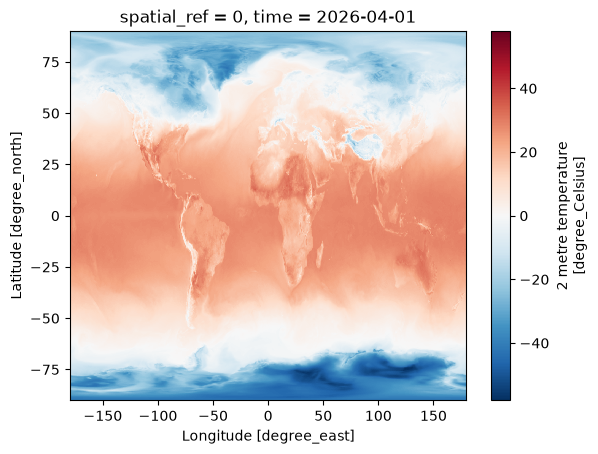

In [4]:
# Plot a global temperature map
analysis["temperature_2m"].sel(time="2026-04-01T00").plot()

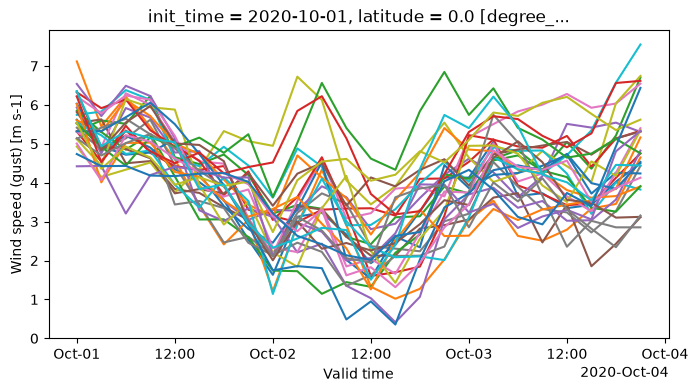

In [5]:
# Ensemble wind gust time-series at a point
_ = (
    forecast_10d["wind_gust_surface"]
    .sel(init_time="2020-10-01T00")
    .sel(lead_time=slice("0d", "2d"))
    .sel(latitude=0, longitude=0)
    .plot(
        x="valid_time", hue="ensemble_member",
        size=4, aspect=2, add_legend=False
    )
)

## How hot did the ensemble expect the July 2022 heat to get?

The United Kingdom passed 40 °C for the first time on 19 July 2022, at RAF Coningsby in Lincolnshire. Let's plot every member of the run issued three days earlier against GEFS's best estimate of what really happened, the analysis.

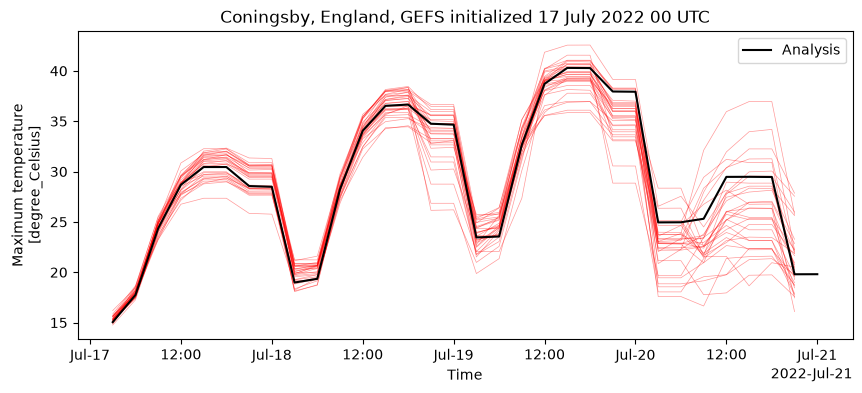

In [6]:
import matplotlib.pyplot as plt

coningsby = {"latitude": 53.09, "longitude": -0.17, "method": "nearest"}

(
    forecast_10d["maximum_temperature_2m"]
    .sel(init_time="2022-07-17T00", lead_time=slice("0d", "3d"))
    .sel(**coningsby)
    .plot(
        x="valid_time", hue="ensemble_member",
        color="red", linewidth=0.5, alpha=0.4,
        add_legend=False, size=4, aspect=2.5,
    )
)
ax = plt.gca()
(
    analysis["maximum_temperature_2m"]
    .sel(time=slice("2022-07-17T03", "2022-07-21T00"))
    .sel(**coningsby)
    .plot(ax=ax, color="black", label="Analysis")
)
ax.legend()
ax.set_title("Coningsby, England, GEFS initialized 17 July 2022 00 UTC");

## How far ahead does each forecast go?

The three forecast datasets differ in how often they start and how far they run. The 10- and 16-day forecasts begin every 6 hours; the 35-day forecast extends only the 00 UTC run.


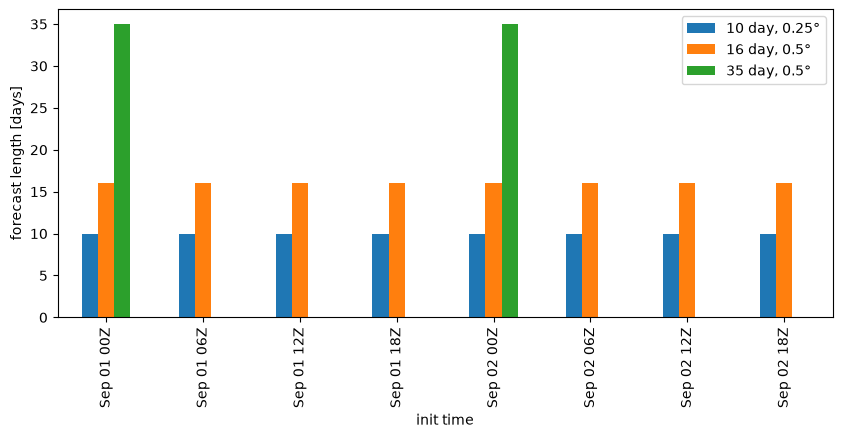

In [7]:
import pandas as pd

window = slice("2026-09-01", "2026-09-02")
forecasts = {
    "10 day, 0.25°": forecast_10d,
    "16 day, 0.5°": forecast_16d,
    "35 day, 0.5°": forecast_35d_pressure,
}

lengths = pd.DataFrame(
    {
        name: pd.Series(
            ds["lead_time"].max().values / pd.Timedelta("1D"),
            index=pd.to_datetime(ds["init_time"].sel(init_time=window).values).strftime("%b %d %HZ"),
        )
        for name, ds in forecasts.items()
    }
)
_ = lengths.plot.bar(figsize=(10, 4), xlabel="init time", ylabel="forecast length [days]")


## Where does the ensemble disagree?

Every forecast here carries 31 members, and their spread is a map of its own. Sunlight reaching the ground depends on clouds, so the members scatter most where they disagree about where the clouds will be, and agree exactly on the night side, where every member reads zero.


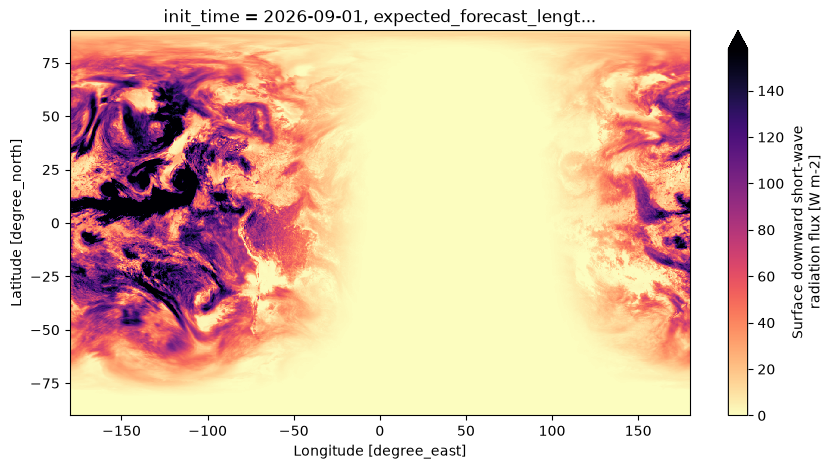

In [8]:
# Spread across the 31 members, three days into one forecast
_ = (
    forecast_10d["downward_short_wave_radiation_flux_surface"]
    .sel(init_time="2026-09-01T00", lead_time="72h")
    .std("ensemble_member")
    .plot(size=5, aspect=2, robust=True, cmap="magma_r")
)


## How does temperature change from the surface up through the atmosphere?

The 0.5 degree forecasts carry 12 variables on 31 pressure levels in the `pressure_level` group. A single colour scale across all three levels shows the air cooling with height.


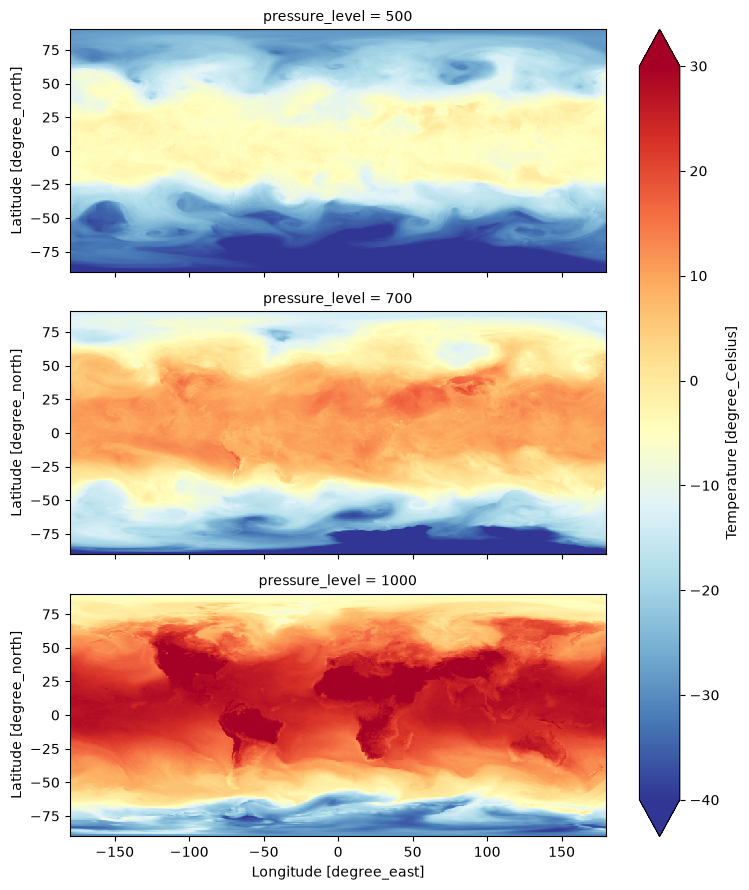

In [9]:
_ = (
    forecast_35d_pressure["temperature"]
    .sel(init_time="2026-09-01T00", lead_time="24h", ensemble_member=0)
    .sel(pressure_level=[500, 700, 1000])
    .assign_coords(pressure_level=lambda da: da["pressure_level"].astype(int))
    .plot(row="pressure_level", vmin=-40, vmax=30, cmap="RdYlBu_r", size=3, aspect=2.2)
)


## What does the wind look like at aviation heights?

The `height_above_mean_sea_level` group carries temperature and wind on 8 fixed heights from 305 to 4572 m. The lower height is blank wherever the ground stands above it, which is most of the land; the upper one shows the jet streams.


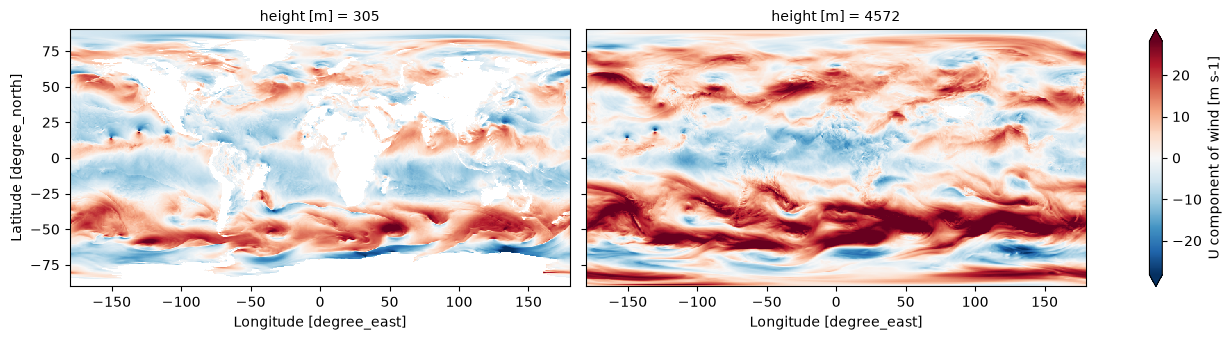

In [10]:
_ = (
    forecast_16d_height["wind_u"]
    .sel(init_time="2026-09-01T00", lead_time="24h", ensemble_member=0)
    .sel(height_above_mean_sea_level=[305, 4572])
    .rename(height_above_mean_sea_level="height [m]")
    .assign_coords({"height [m]": lambda da: da["height [m]"].astype(int)})
    .plot(col="height [m]", size=3.5, aspect=1.8, robust=True, cmap="RdBu_r")
)


## Community challenge

- Ensemble spread grows with lead time, but not evenly everywhere. Map it at day 1, day 5 and day 10 and see which regions lose predictability first.
- The `pressure_level` group carries icing probability and severity at six levels between 800 and 300 hPa. Where and when does the model expect icing along a route you care about?
- The analysis reaches back to October 2020 at 3-hourly steps. Pick a variable and find the extreme: where and when was it largest? Then check the forecast datasets — how far ahead did GEFS forecast it?
